In [1]:
from function_lib import *

In [ ]:
# ----------------- config -----------------
n_instance   = 1000
input_dim    = 5
noise        = 0.5
deg          = 2
grid_width   = 5
epoch        = 100
learning_rate = 0.001
n_simulation = 50

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

# ----------------- results ----------------
total_result  = {}
# =========================================================
# main loop over seeds
# =========================================================
for model_type in ["LST"]:
    regret_result = []
    parame_result = []

    # ----- build Z (all feasible z) only once -----
    sols, edges, G = generate_all_feasible_solutions(grid_width=5)

    solver = None  # will build once on the first iteration

    for seed in tqdm(range(n_simulation),
                     desc="Running simulations",
                     colour="green"):

        # ---- reproducibility ----
        random.seed(seed)
        np.random.seed(seed)

        # ---- data for this seed ----
        x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
            base, n_instance, input_dim, deg, noise, grid_width, seed
        )

        # ---- build solver only once (reuse the same model) ----
        if solver is None:
            solver = LSTECPParam(
                N=x_train.shape[0],       # must be constant across seeds
                d_x=x_train.shape[1],
                d_c=y_train.shape[1],
                Z=sols,                   # Z is fixed set of feasible decisions
                eta=0.5
            )

        # ---- solve training problem for this seed ----
        res = solver.solve(x_train, y_train, verbose=False)

        # ---- evaluate regret on test set ----
        # B is already stored in solver.B after solve(), so B argument is optional
        eval_res = solver.evaluate_regret(
            x_test, y_test, return_per_sample=False
        )

        regret_result.append(eval_res["avg_regret"])
        parame_result.append(res["B"])

    # save results for this model type
    total_result[model_type] = {
        "regret": regret_result,
        "params": parame_result
    }


# Save the result to pickle file
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)   # create directory if not exist
file_path = os.path.join(save_path, f"Shortest_path_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl")
with open(file_path, "wb") as f:
    pickle.dump(total_result, f)


Running simulations: 100%|██████████| 50/50 [04:12<00:00,  5.05s/it]


Mean    : 6.940461
Std     : 0.835282
VaR 90  : 8.298895
CVaR 90 : 8.564543


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_4240\3756076232.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


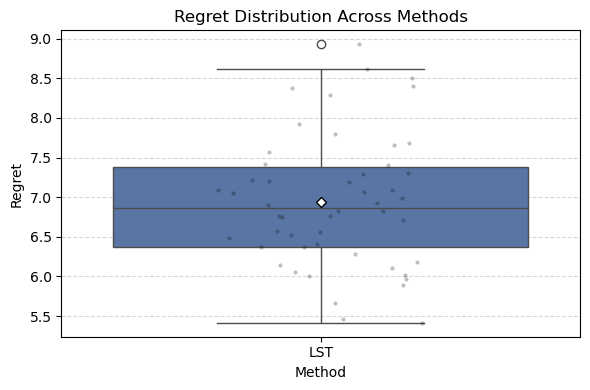

In [5]:
# Compute stats for the LST model
regrets = total_result["LST"]["regret"]

mean, std, var90, cvar90 = compute_stats(regrets)

print(f"Mean    : {mean:.6f}")
print(f"Std     : {std:.6f}")
print(f"VaR 90  : {var90:.6f}")
print(f"CVaR 90 : {cvar90:.6f}")

# Collect regret distributions across all model types
df_list = []
for model_type, data in total_result.items():
    df_list.append(pd.DataFrame({
        "method": [model_type] * len(data["regret"]),
        "regret": data["regret"]
    }))

df = pd.concat(df_list, ignore_index=True)

# Academic color palette
palette = sns.color_palette("deep")
unique_methods = sorted(df["method"].unique())
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(unique_methods)}

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution Across Methods", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "regret_comparison.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [3]:
# seed = 1
# x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed)

# # Example usage:

# sols, edges, G = generate_all_feasible_solutions(grid_width=5)
# print("Number of edges:", len(edges))
# print("Number of feasible s->t paths:", len(sols))
# print("First solution vector:", sols[0])

# # pick any solution
# vec = sols[10]
# # draw
# draw_solution(G, edges, vec, grid_width=5, cost=y_train[0])
# solver = LSTECPParam(
#     N=x_train.shape[0],
#     d_x=x_train.shape[1],
#     d_c=y_train.shape[1],
#     Z=sols,
#     eta=0.5
# )

# X_run = x_train   # shape (N, d_x)
# C_run = y_train   # shape (N, d_c)

# res = solver.solve(X_run, C_run, verbose=False)
# eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=True)
# print("Avg regret:", eval_res["avg_regret"])
# # print("Per-sample regret:", eval_res["regret_per_sample"])
